In [11]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [12]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s4e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e8/train.csv
/kaggle/input/competitions/playground-series-s4e8/test.csv


In [13]:
data_train = pd.read_csv('/kaggle/input/competitions/playground-series-s4e8/train.csv')
data_test = pd.read_csv('/kaggle/input/competitions/playground-series-s4e8/test.csv')

# Inital Analysis

In [14]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3116945 entries, 0 to 3116944
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   class                 object 
 2   cap-diameter          float64
 3   cap-shape             object 
 4   cap-surface           object 
 5   cap-color             object 
 6   does-bruise-or-bleed  object 
 7   gill-attachment       object 
 8   gill-spacing          object 
 9   gill-color            object 
 10  stem-height           float64
 11  stem-width            float64
 12  stem-root             object 
 13  stem-surface          object 
 14  stem-color            object 
 15  veil-type             object 
 16  veil-color            object 
 17  has-ring              object 
 18  ring-type             object 
 19  spore-print-color     object 
 20  habitat               object 
 21  season                object 
dtypes: float64(3), int64(1), object(18)
memory

In [15]:
data_train.head(3)

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,...,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2,e,6.94,f,s,b,f,x,c,w,...,NaN,s,n,NaN,NaN,f,f,NaN,l,w


In [16]:
data_train.describe(include='number')

,id,cap-diameter,stem-height,stem-width
count,3.116945e+06,3.116941e+06,3.116945e+06,3.116945e+06
mean,1.558472e+06,6.309848e+00,6.348333e+00,1.115379e+01
std,8.997847e+05,4.657931e+00,2.699755e+00,8.095477e+00
min,0.000000e+00,3.000000e-02,0.000000e+00,0.000000e+00
25%,7.792360e+05,3.320000e+00,4.670000e+00,4.970000e+00
50%,1.558472e+06,5.750000e+00,5.880000e+00,9.650000e+00
75%,2.337708e+06,8.240000e+00,7.410000e+00,1.563000e+01
max,3.116944e+06,8.067000e+01,8.872000e+01,1.029000e+02


In [17]:
data_train.describe(include='O').T

,count,unique,top,freq
class,3116945,2,p,1705396
cap-shape,3116905,74,x,1436026
cap-surface,2445922,83,t,460777
cap-color,3116933,78,n,1359542
does-bruise-or-bleed,3116937,26,f,2569743
gill-attachment,2593009,78,a,646034
gill-spacing,1858510,48,c,1331054
gill-color,3116888,63,w,931538
stem-root,359922,38,b,165801
stem-surface,1136084,60,s,327610


In [18]:
column_numerical = ['cap-diameter', 'stem-height', 'stem-width']
column_categorical = ['class','season', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
                      'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat']

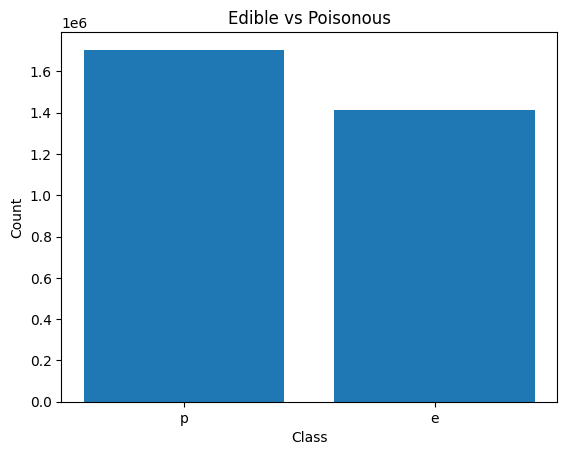

In [19]:
counts = data_train["class"].value_counts()
plt.bar(counts.index, counts.values)
plt.title('Edible vs Poisonous')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()
# balanced dataset

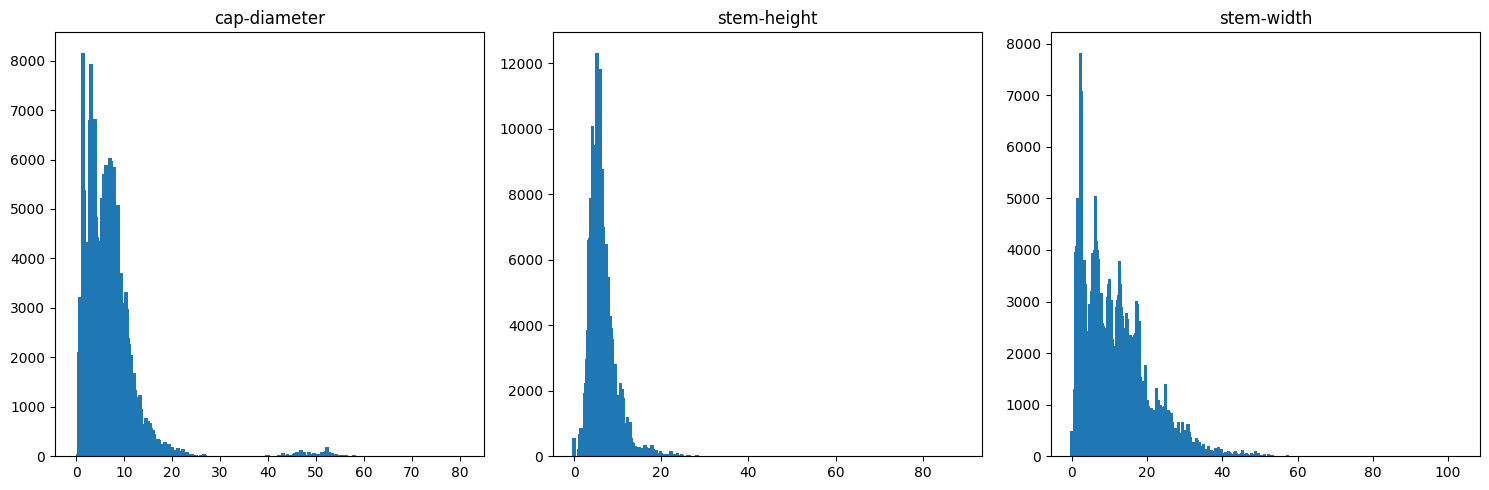

In [20]:
fig, ax = plt.subplots(1,3, figsize=(15, 5))
ax = ax.flatten()
for idx, c in enumerate(column_numerical):
    counts = data_train[c].value_counts()
    ax[idx].bar(counts.index, counts.values)
    ax[idx].set_title(c)

plt.tight_layout()
plt.show()

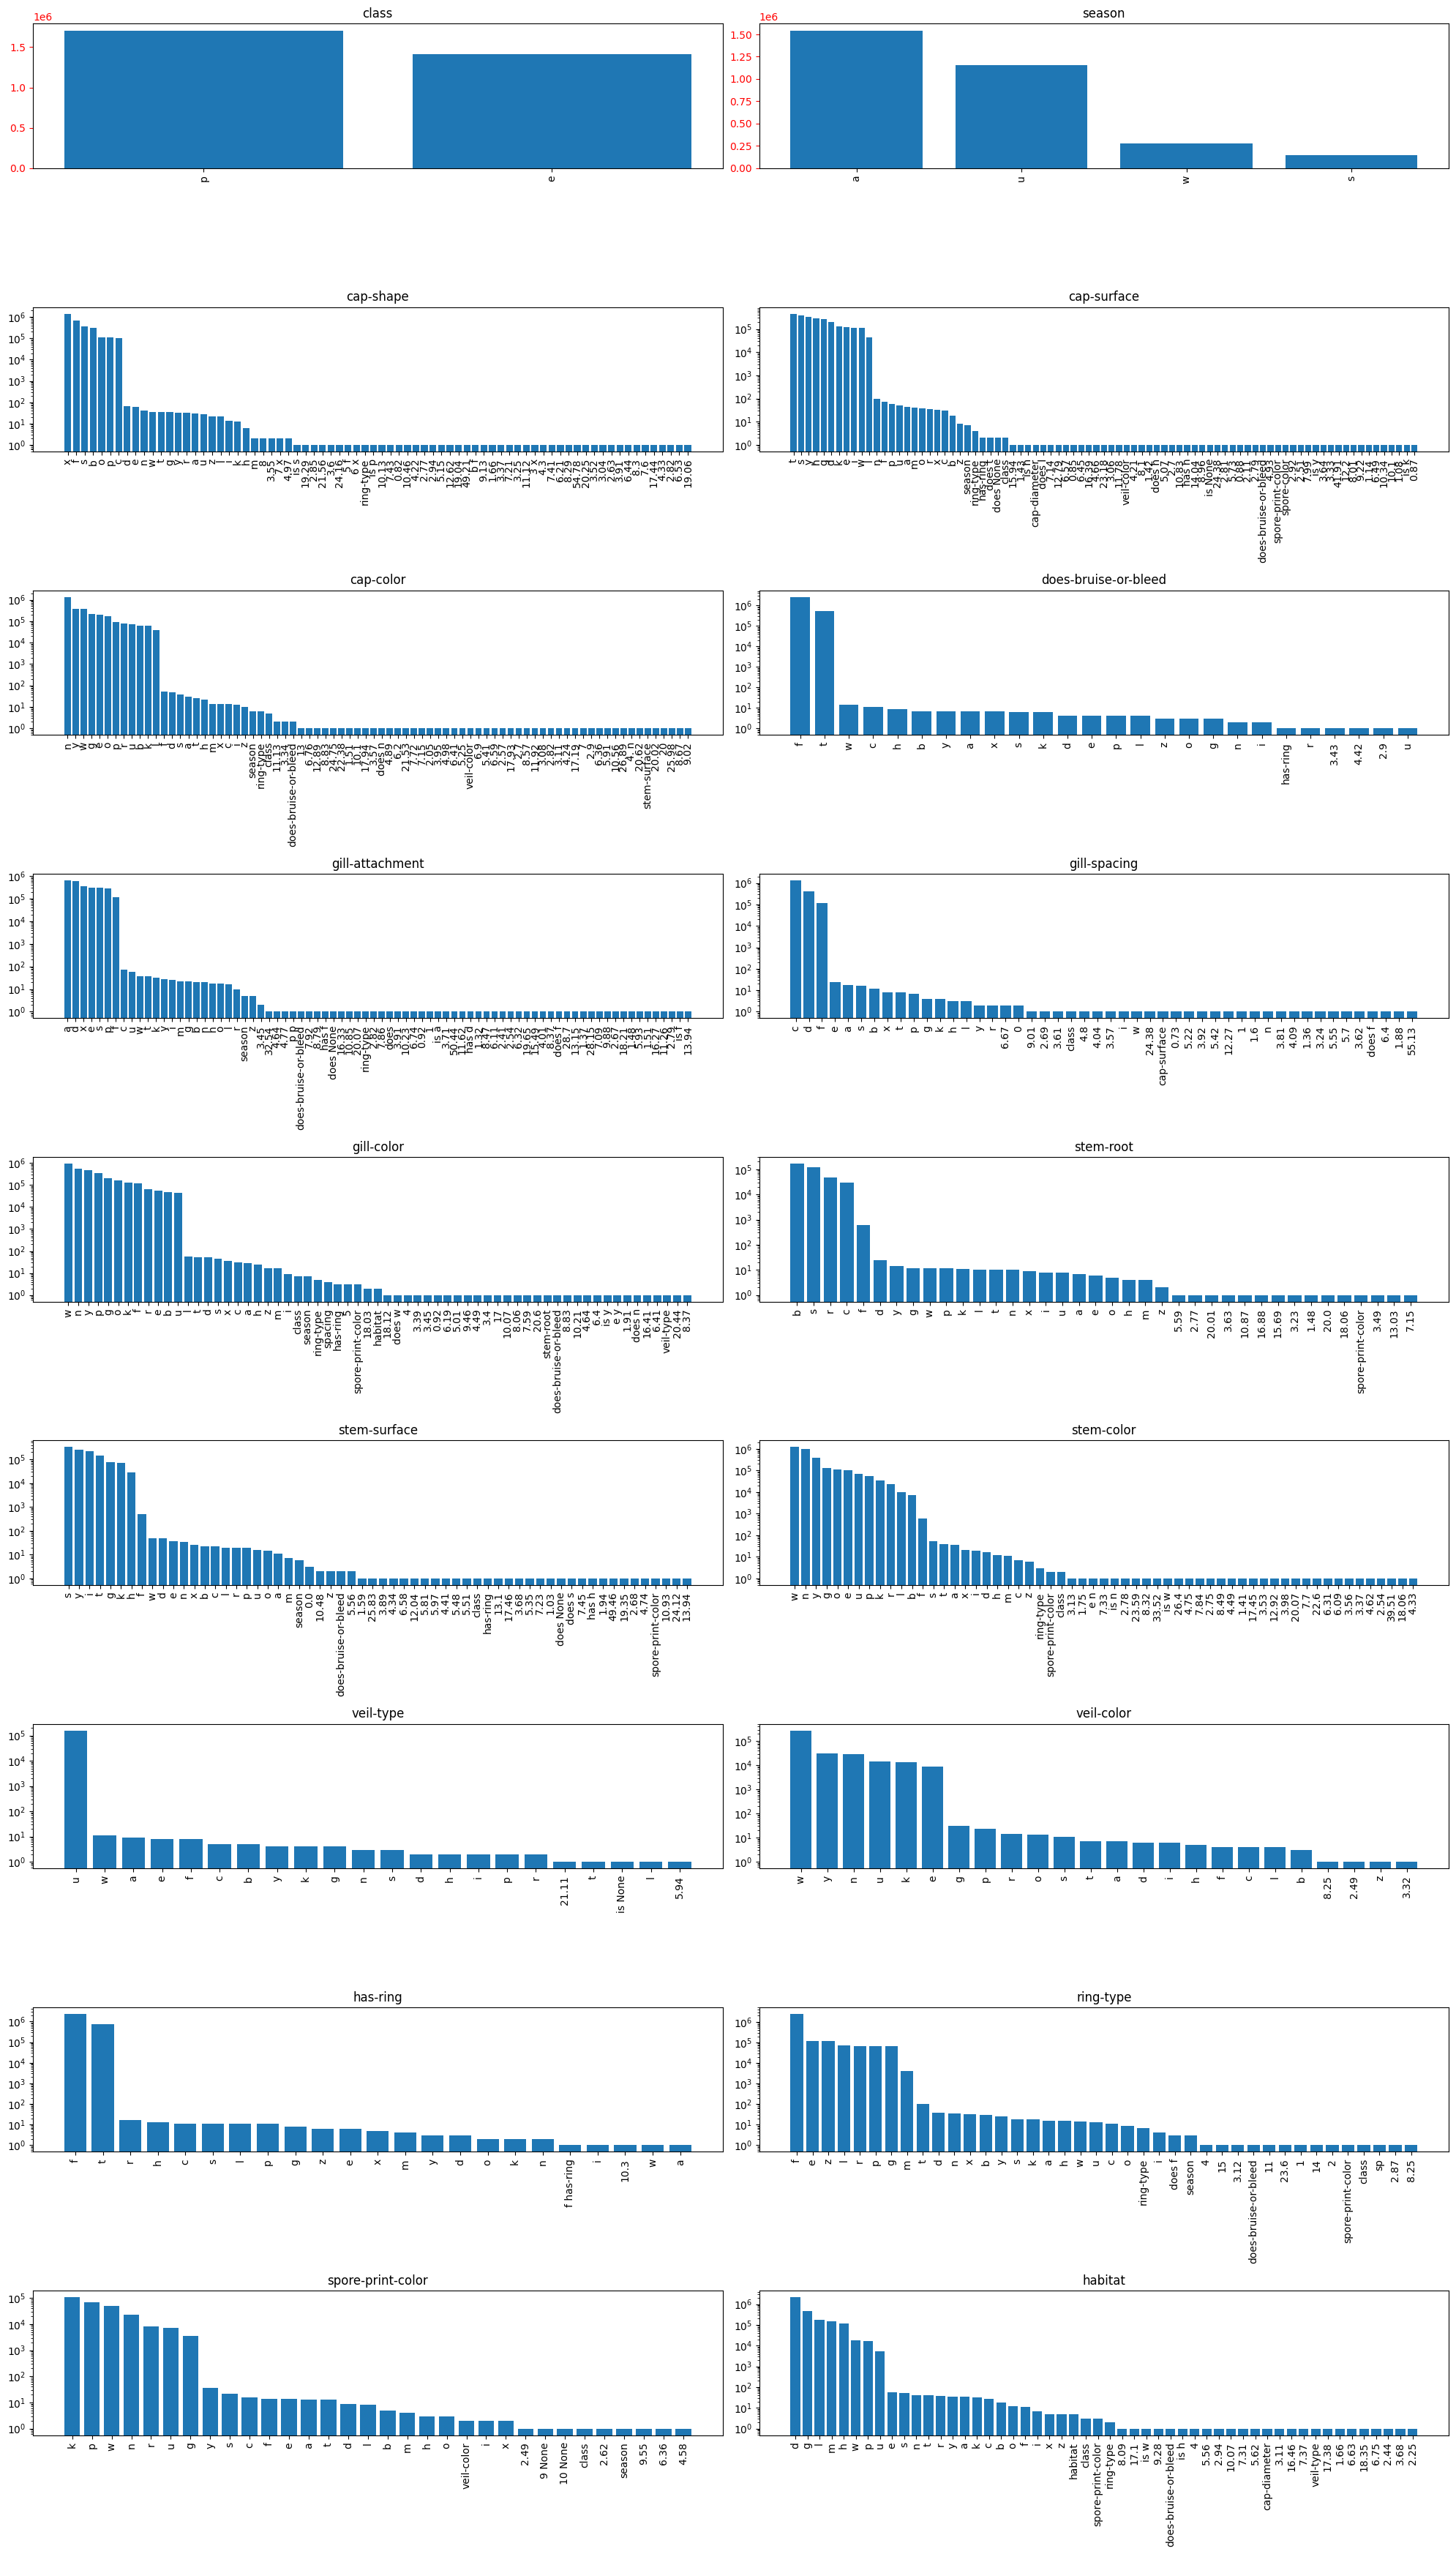

In [21]:
fig, ax = plt.subplots(9,2, figsize=(20, 35))
ax = ax.flatten()

for idx, c in enumerate(column_categorical):
    counts = data_train[c].value_counts()
    ax[idx].bar(counts.index, counts.values)
    ax[idx].set_title(c)
    ax[idx].tick_params(axis='x', rotation=90)
    ax[idx].set_yscale("log")

    # log scale cuz the rarer classes are invisible otherwise
    if c  in ["class", "season"]:
        ax[idx].set_yscale("linear")
        ax[idx].tick_params(axis='y', colors='red')


plt.tight_layout()
plt.show()

# Data Cleaning
Classes with > 40% of their data missing might not be useful

In [22]:
missing_values_df = pd.DataFrame()
missing_values_df["# Missing"] = data_train.isnull().sum()
missing_values_df["% Missing"] = missing_values_df["# Missing"] / len(data_train) * 100
display(missing_values_df)

,# Missing,% Missing
id,0,0.000000
class,0,0.000000
cap-diameter,4,0.000128
cap-shape,40,0.001283
cap-surface,671023,21.528227
cap-color,12,0.000385
does-bruise-or-bleed,8,0.000257
gill-attachment,523936,16.809280
gill-spacing,1258435,40.373988
gill-color,57,0.001829


In [23]:
column_drop = ["id", "stem-root", "stem-surface", "veil-type", "veil-color", "spore-print-color", 'gill-spacing',]
column_reduced_categorical = ['season', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment',  'gill-color',
                       'stem-color',  'has-ring', 'ring-type', 'habitat']

data_train = data_train.drop(columns=column_drop)
data_test = data_test.drop(columns=column_drop)

In [24]:
imputer_numerical = SimpleImputer(strategy='mean')
data_train[column_numerical] = imputer_numerical.fit_transform(data_train[column_numerical])
data_test[column_numerical] = imputer_numerical.transform(data_test[column_numerical])

imputer_categorical = SimpleImputer(strategy='most_frequent')
data_train[column_reduced_categorical] = imputer_categorical.fit_transform(data_train[column_reduced_categorical])
data_test[column_reduced_categorical] = imputer_categorical.transform(data_test[column_reduced_categorical])

In [25]:
missing_values_df = pd.DataFrame()
missing_values_df["# Missing"] = data_train.isnull().sum()
missing_values_df["% Missing"] = missing_values_df["# Missing"] / len(data_train) * 100
display(missing_values_df)

,# Missing,% Missing
class,0,0.0
cap-diameter,0,0.0
cap-shape,0,0.0
cap-surface,0,0.0
cap-color,0,0.0
does-bruise-or-bleed,0,0.0
gill-attachment,0,0.0
gill-color,0,0.0
stem-height,0,0.0
stem-width,0,0.0


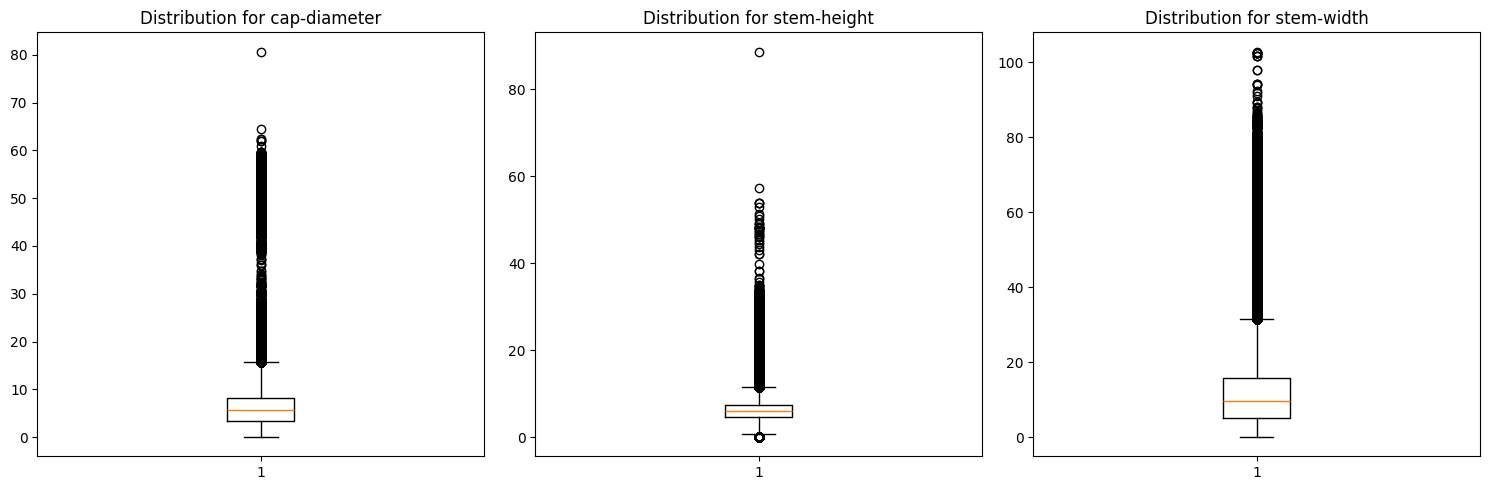

In [26]:
fig, ax = plt.subplots(1,3, figsize=(15, 5))
ax = ax.flatten()

for idx, col in enumerate(column_numerical):
    ax[idx].boxplot(x=data_train[col])
    ax[idx].set_title(f"Distribution for {col}")


plt.tight_layout()
plt.show()

In [27]:
for col in column_numerical:
    col_mean = data_train[col].mean()
    col_std = data_train[col].std()
    
    lower_bound = 0
    upper_bound = col_mean + (3 * col_std)

    data_train[col] = data_train[col].clip(lower=lower_bound, upper=upper_bound)
    data_test[col] = data_test[col].clip(lower=lower_bound, upper=upper_bound)

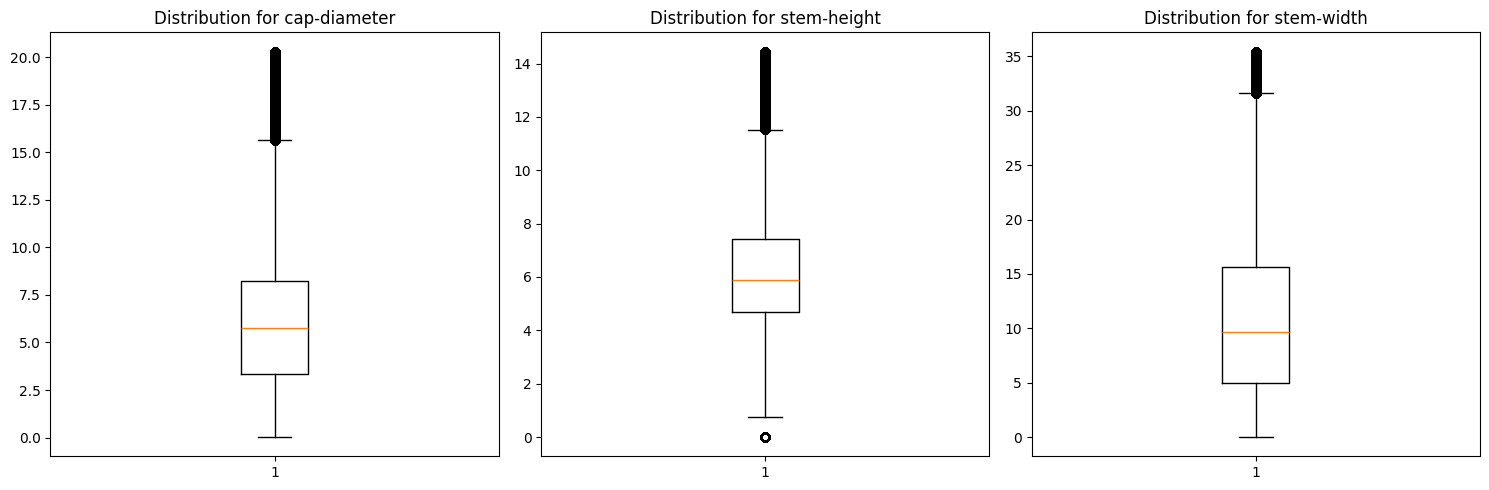

In [28]:
fig, ax = plt.subplots(1,3, figsize=(15, 5))
ax = ax.flatten()

for idx, col in enumerate(column_numerical):
    ax[idx].boxplot(x=data_train[col])
    ax[idx].set_title(f"Distribution for {col}")


plt.tight_layout()
plt.show()

In [29]:
num_categories = pd.DataFrame()
num_categories["num_categories"] = data_train[column_reduced_categorical].nunique()
display(num_categories)
# too many for one hot, but most located in few classes => sort rest into "other" class

,num_categories
season,4
cap-shape,74
cap-surface,83
cap-color,78
does-bruise-or-bleed,26
gill-attachment,78
gill-color,63
stem-color,59
has-ring,23
ring-type,40


In [30]:

threshold = 0.05 # replace classes with less than 5% of elements

for col in column_reduced_categorical:
    freq = data_train[col].value_counts()
    top_classes = freq.index[(freq.values / len(data_train)) > threshold]
    data_train.loc[~data_train[col].isin(top_classes), col] = "other"
    data_test.loc[~data_test[col].isin(top_classes), col] = "other"

In [31]:
num_categories = pd.DataFrame()
num_categories["num_categories"] = data_train[column_reduced_categorical].nunique()
display(num_categories)

,num_categories
season,4
cap-shape,5
cap-surface,7
cap-color,7
does-bruise-or-bleed,3
gill-attachment,7
gill-color,7
stem-color,4
has-ring,3
ring-type,2


In [32]:
num_categories = pd.DataFrame()
num_categories["num_categories"] = data_test[column_reduced_categorical].nunique()
display(num_categories)

,num_categories
season,4
cap-shape,5
cap-surface,7
cap-color,7
does-bruise-or-bleed,3
gill-attachment,7
gill-color,7
stem-color,4
has-ring,3
ring-type,2


In [33]:
print(f"train columns: {data_train.columns} ({len(data_train.columns)})")
print(f"test columns: {data_test.columns} ({len(data_test.columns)})")

train columns: Index(['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-color', 'stem-height',
       'stem-width', 'stem-color', 'has-ring', 'ring-type', 'habitat',
       'season'],
      dtype='object') (15)
test columns: Index(['cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-color', 'stem-height',
       'stem-width', 'stem-color', 'has-ring', 'ring-type', 'habitat',
       'season'],
      dtype='object') (14)


In [34]:
encoder_onehot= OneHotEncoder(categories='auto',handle_unknown='ignore', sparse_output=False)
train_encoded = encoder_onehot.fit_transform(data_train[column_reduced_categorical])
test_encoded = encoder_onehot.transform(data_test[column_reduced_categorical])

encoded_cols = encoder_onehot.get_feature_names_out(column_reduced_categorical)

train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=data_train.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=data_test.index)

data_train = pd.concat([data_train.drop(columns=column_reduced_categorical), train_encoded_df], axis=1)
data_test = pd.concat([data_test.drop(columns=column_reduced_categorical), test_encoded_df], axis=1)

data_train['class'] = data_train['class'].map({'e':0,'p':1})

In [35]:
print(f"train columns: {data_train.columns} ({len(data_train.columns)})")
print(f"test columns: {data_test.columns} ({len(data_test.columns)})")

train columns: Index(['class', 'cap-diameter', 'stem-height', 'stem-width', 'season_a',
       'season_other', 'season_u', 'season_w', 'cap-shape_b', 'cap-shape_f',
       'cap-shape_other', 'cap-shape_s', 'cap-shape_x', 'cap-surface_d',
       'cap-surface_g', 'cap-surface_h', 'cap-surface_other', 'cap-surface_s',
       'cap-surface_t', 'cap-surface_y', 'cap-color_e', 'cap-color_g',
       'cap-color_n', 'cap-color_o', 'cap-color_other', 'cap-color_w',
       'cap-color_y', 'does-bruise-or-bleed_f', 'does-bruise-or-bleed_other',
       'does-bruise-or-bleed_t', 'gill-attachment_a', 'gill-attachment_d',
       'gill-attachment_e', 'gill-attachment_other', 'gill-attachment_p',
       'gill-attachment_s', 'gill-attachment_x', 'gill-color_g',
       'gill-color_n', 'gill-color_o', 'gill-color_other', 'gill-color_p',
       'gill-color_w', 'gill-color_y', 'stem-color_n', 'stem-color_other',
       'stem-color_w', 'stem-color_y', 'has-ring_f', 'has-ring_other',
       'has-ring_t', 'ring-t

In [36]:
x_train = data_train.drop('class', axis=1)
y_train = data_train['class']

x_test = data_test.copy()

# Training

In [51]:
from sklearn import tree, ensemble, linear_model
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_validate, train_test_split

In [38]:
MLA = [
    # hist allows approximate splits by binning values instead of calculating exact (much slower)
    XGBClassifier(tree_method='hist', device='cuda'), 
    LogisticRegression(n_jobs=-1, max_iter=1000),
    ensemble.HistGradientBoostingClassifier(max_iter=100)
]

strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mla_results = []
fitted_models = {}


for row_idx, alg in enumerate(MLA):
    MLA_name = alg.__class__.__name__
    print(f"Current model: {MLA_name}")

    cv_results = cross_validate(alg, x_train, y_train, cv=strat_kfold,return_train_score=True)

    mla_results.append({
        'MLA Name': MLA_name,
        'MLA Parameters': str(alg.get_params()),
        'MLA Train Accuracy Mean': cv_results['train_score'].mean(),
        'MLA Val Accuracy Mean': cv_results['test_score'].mean(),
        'MLA Time': cv_results['fit_time'].mean()
    })
    
    alg.fit(x_train, y_train)
    fitted_models[MLA_name] = alg

MLA_compare = pd.DataFrame(mla_results)
MLA_compare.sort_values(by=['MLA Val Accuracy Mean'], ascending=False, inplace=True)
display(MLA_compare)

Current model: XGBClassifier


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [19:06:06] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Current model: LogisticRegression
Current model: HistGradientBoostingClassifier


,MLA Name,MLA Parameters,MLA Train Accuracy Mean,MLA Val Accuracy Mean,MLA Time
0,XGBClassifier,"{'objective': 'binary:logistic', 'base_score':...",0.987151,0.986824,8.079795
2,HistGradientBoostingClassifier,"{'categorical_features': 'from_dtype', 'class_...",0.981358,0.981293,58.637857
1,LogisticRegression,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.719775,0.719739,41.888315


Text(0, 0.5, 'Algorithm')

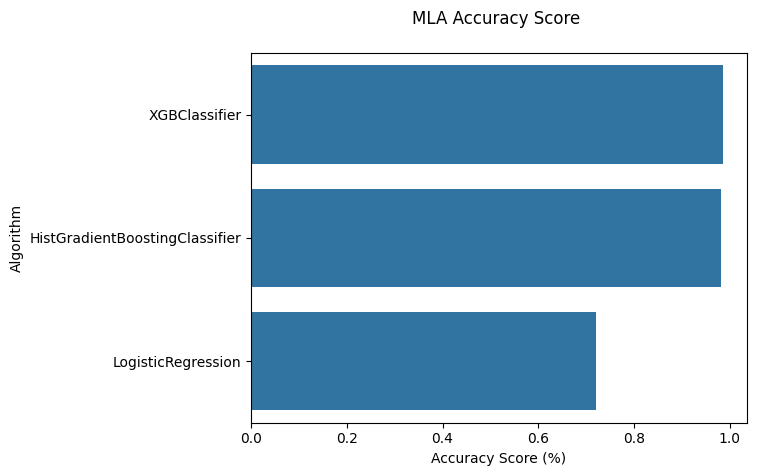

In [39]:
sns.barplot(x='MLA Val Accuracy Mean', y = 'MLA Name', data = MLA_compare)
plt.title('MLA Accuracy Score \n')
plt.xlabel('Accuracy Score (%)')
plt.ylabel('Algorithm')

# Submission 1: XGB
**Score: 0.97393**

In [40]:
submission = pd.DataFrame()

xgb_model = fitted_models.get("XGBClassifier")
y_pred_numeric = xgb_model.predict(x_test)

raw_test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s4e8/test.csv')
submission["id"] = raw_test_data["id"]

submission["class"] = y_pred_numeric
submission["class"] = submission["class"].map({0: 'e', 1: 'p'})
submission.to_csv("submission_xgb_v1.csv", index=False)

# Features Analysis

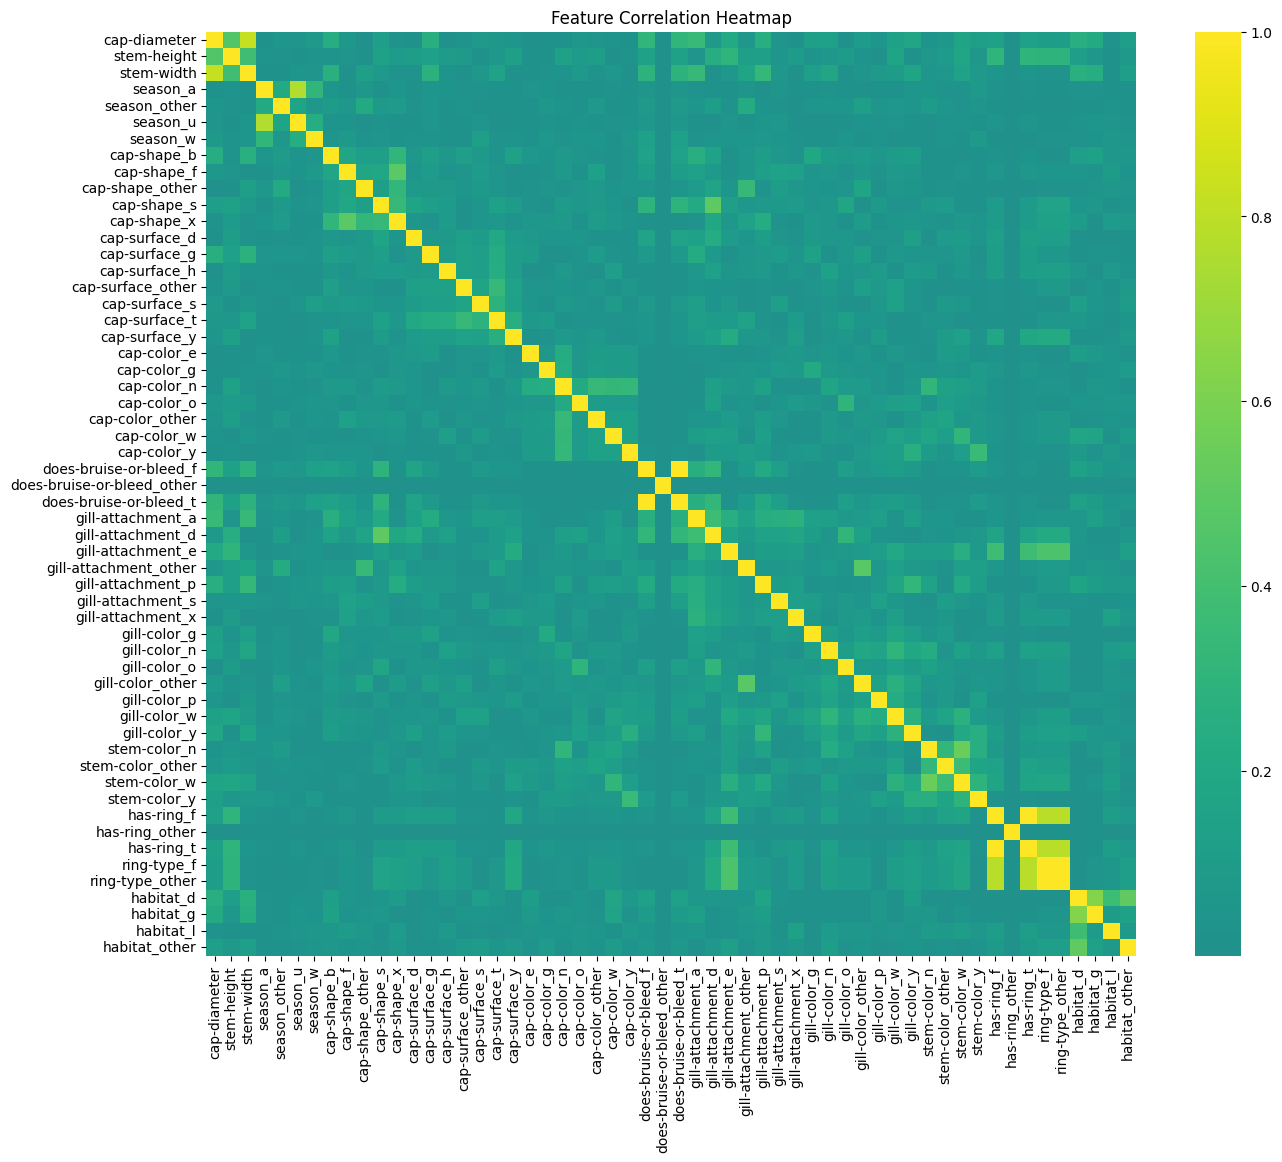

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr_matrix = x_train.corr().abs()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, cmap='viridis', center=0, annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

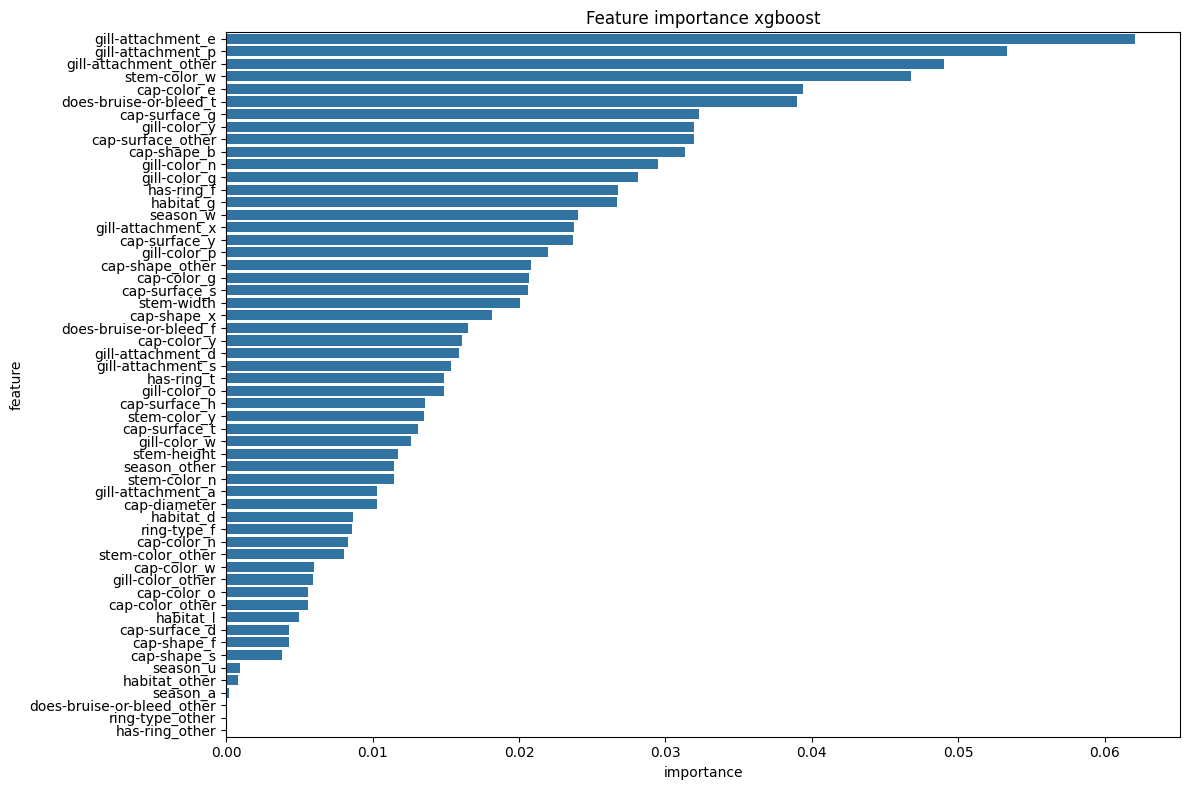

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

xgb_model = fitted_models.get("XGBClassifier")

importance_df = pd.DataFrame({
    'feature': x_train.columns,
    'importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature importance xgboost')
plt.xlabel('importance')
plt.ylabel('feature')
plt.tight_layout()
plt.show()


importance_xgb_columns = importance_df['feature'][:20]

## Shap
used to "measure the overall importance of a feature"

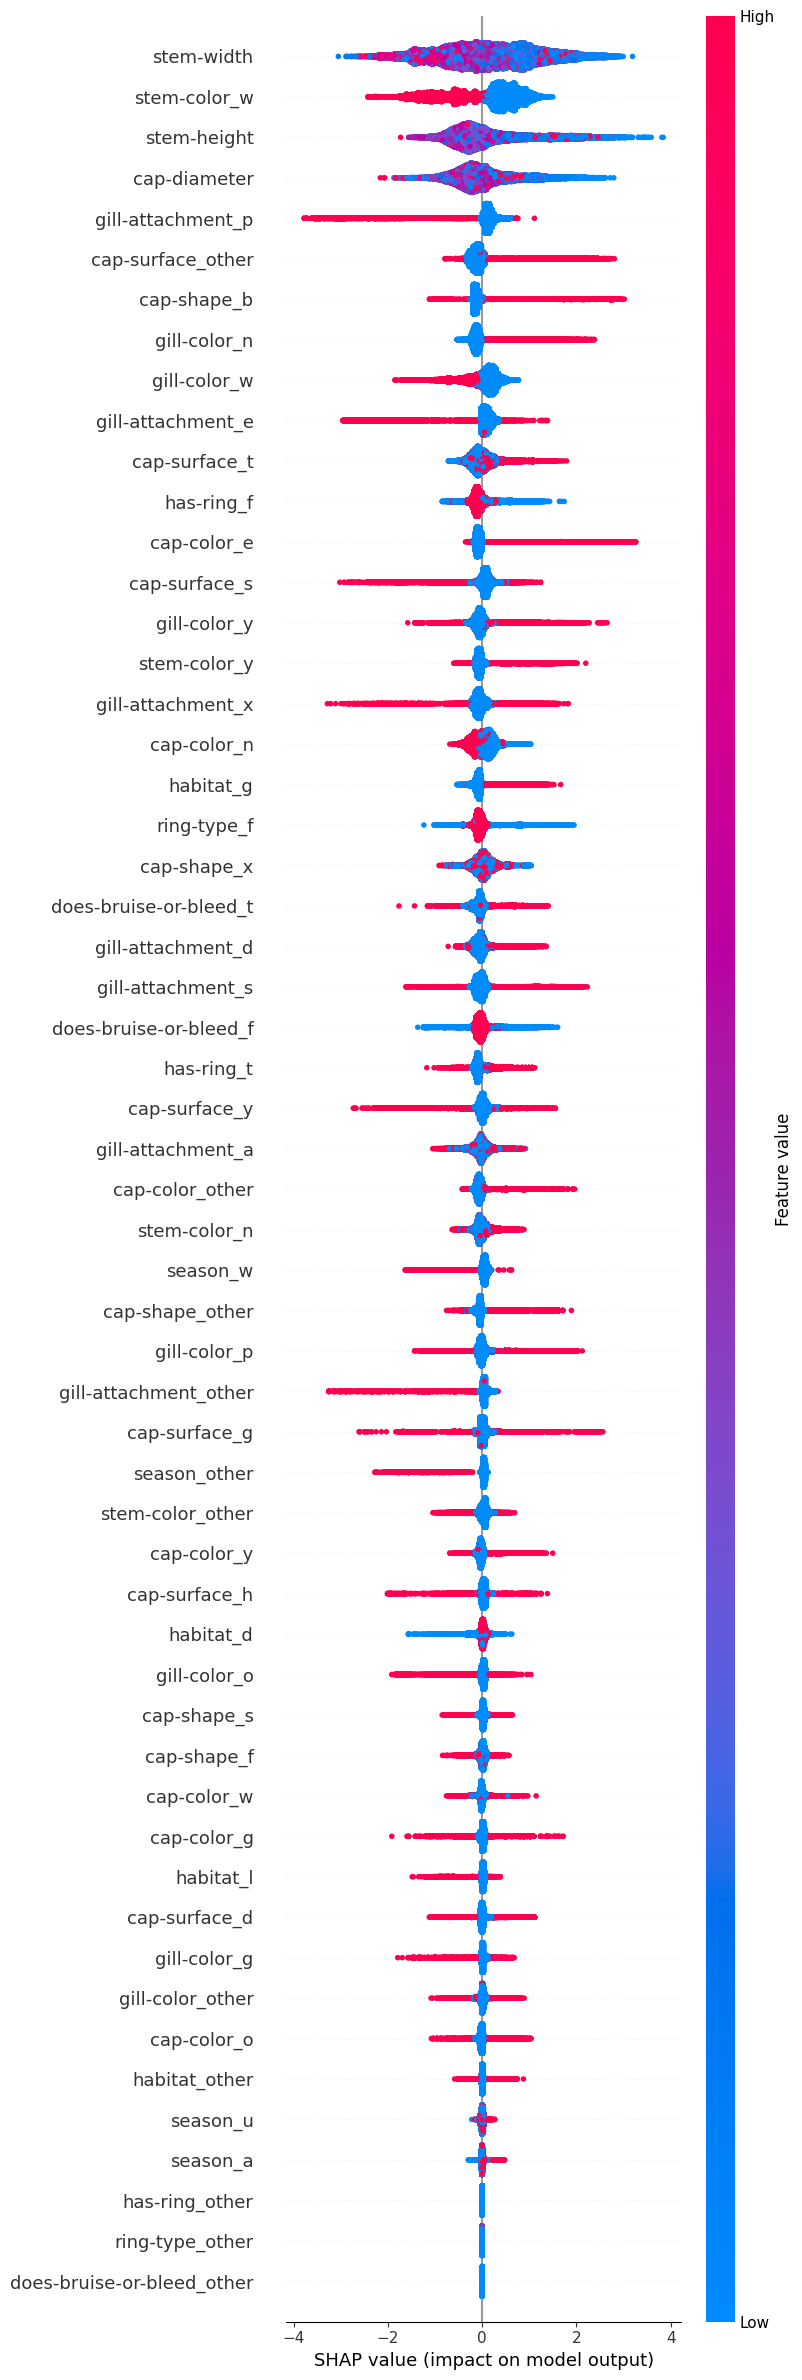

In [43]:
import shap

x_sample = x_train.sample(n=50000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(x_sample)

shap.summary_plot(shap_values, x_sample, max_display=60)

In [44]:
mean_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    'feature': x_sample.columns,
    'importance': mean_shap
})

shap_importance_df = shap_importance_df.sort_values(by='importance', ascending=False)

importance_shap_columns = shap_importance_df['feature'][:20]

In [45]:
combined_features = list(set(importance_shap_columns) | set(importance_xgb_columns))

print(f"Best features from union (Total: {len(combined_features)}):\n{combined_features}")

Best features from union (Total: 29):
['cap-surface_s', 'stem-width', 'cap-diameter', 'cap-shape_other', 'gill-attachment_other', 'gill-color_n', 'cap-color_g', 'gill-attachment_e', 'stem-height', 'gill-color_y', 'has-ring_f', 'gill-color_p', 'cap-surface_g', 'gill-attachment_x', 'habitat_g', 'season_w', 'does-bruise-or-bleed_t', 'cap-shape_b', 'cap-surface_y', 'gill-attachment_p', 'cap-surface_t', 'cap-surface_other', 'cap-color_n', 'gill-color_w', 'cap-color_e', 'ring-type_f', 'gill-color_g', 'stem-color_w', 'stem-color_y']


In [46]:
x_train_reduced = x_train[combined_features]
x_test_reduced = x_test[combined_features]

In [47]:
MLA = [
    # hist allows approximate splits by binning values instead of calculating exact (much slower)
    XGBClassifier(tree_method='hist', device='cuda'), 
    LogisticRegression(n_jobs=-1, max_iter=1000),
    ensemble.HistGradientBoostingClassifier(max_iter=100)
]

strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mla_results = []
fitted_models_v2 = {}


for row_idx, alg in enumerate(MLA):
    MLA_name = alg.__class__.__name__
    print(f"Current model: {MLA_name}")

    cv_results = cross_validate(alg, x_train_reduced, y_train, cv=strat_kfold,return_train_score=True)

    mla_results.append({
        'MLA Name': MLA_name,
        'MLA Parameters': str(alg.get_params()),
        'MLA Train Accuracy Mean': cv_results['train_score'].mean(),
        'MLA Val Accuracy Mean': cv_results['test_score'].mean(),
        'MLA Time': cv_results['fit_time'].mean()
    })
    
    alg.fit(x_train_reduced, y_train)
    fitted_models[f"{MLA_name}_v2"] = alg

MLA_compare = pd.DataFrame(mla_results)
MLA_compare.sort_values(by=['MLA Val Accuracy Mean'], ascending=False, inplace=True)
display(MLA_compare)

Current model: XGBClassifier
Current model: LogisticRegression
Current model: HistGradientBoostingClassifier


,MLA Name,MLA Parameters,MLA Train Accuracy Mean,MLA Val Accuracy Mean,MLA Time
0,XGBClassifier,"{'objective': 'binary:logistic', 'base_score':...",0.984227,0.983830,4.776484
2,HistGradientBoostingClassifier,"{'categorical_features': 'from_dtype', 'class_...",0.977228,0.977160,35.551445
1,LogisticRegression,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.704799,0.704759,46.609117


Text(0, 0.5, 'Algorithm')

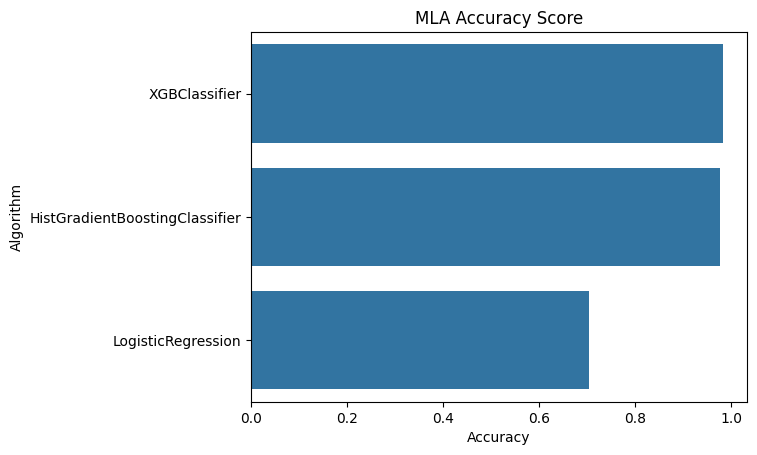

In [48]:
sns.barplot(x='MLA Val Accuracy Mean', y = 'MLA Name', data = MLA_compare)
plt.title('MLA Accuracy Score')
plt.xlabel('Accuracy')
plt.ylabel('Algorithm')

# Submission 2: XGB reduced
**Score: 0.96738**

In [49]:
submission = pd.DataFrame()

xgb_model_v2 = fitted_models.get("XGBClassifier_v2")
y_pred_numeric = xgb_model_v2.predict(x_test_reduced)

raw_test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s4e8/test.csv')
submission["id"] = raw_test_data["id"]

submission["class"] = y_pred_numeric
submission["class"] = submission["class"].map({0: 'e', 1: 'p'})
submission.to_csv("submission_xgb_v2.csv", index=False)

# Hyperparameter Search
## Optuna
optimizing XGBoost due to consistent best performance using Optuna (hyperparameter optimization framework)

In [52]:
import optuna

x_tuning, x_val, y_tuning, y_val = train_test_split(x_train_reduced, y_train, test_size=0.2, stratify=y_train, random_state=42)

def objective(trial):
    param = {
        'tree_method': 'hist',
        'device': 'cuda',
        'n_estimators': 1000, # num trees, higher than needed, stopped early 
        'early_stopping_rounds':20, # stop optimizing if val set performance doesn't improve in n rounds

        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        # 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }

    model = XGBClassifier(**param)

    model.fit(
            x_tuning, y_tuning,
            eval_set=[(x_val, y_val)],
            verbose=False
        )
    preds = model.predict(x_val)
    accuracy = (preds == y_val).mean()
    
    return accuracy

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"Best Accuracy: {study.best_value:.5f}")
for key, value in study.best_params.items():
    print(f"'{key}': {value}")

[I 2026-04-19 19:32:24,994] A new study created in memory with name: no-name-acb709e8-ae26-4c79-b3ee-eec9288aa04f
[I 2026-04-19 19:32:35,771] Trial 0 finished with value: 0.9855499535602971 and parameters: {'learning_rate': 0.2966240869132493, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.8664376900512888}. Best is trial 0 with value: 0.9855499535602971.
[I 2026-04-19 19:33:00,821] Trial 1 finished with value: 0.979226454108109 and parameters: {'learning_rate': 0.010151045335106638, 'max_depth': 7, 'min_child_weight': 3, 'subsample': 0.6298543122647833}. Best is trial 0 with value: 0.9855499535602971.
[I 2026-04-19 19:33:18,323] Trial 2 finished with value: 0.9582379541506186 and parameters: {'learning_rate': 0.016001883498415043, 'max_depth': 4, 'min_child_weight': 9, 'subsample': 0.8110242819472041}. Best is trial 0 with value: 0.9855499535602971.
[I 2026-04-19 19:33:35,986] Trial 3 finished with value: 0.9847446778817079 and parameters: {'learning_rate': 0.22246495481805575,

Best Accuracy: 0.98607
'learning_rate': 0.06527497599076386
'max_depth': 9
'min_child_weight': 7
'subsample': 0.7950227676127473


In [55]:
best_params = study.best_params

best_params['tree_method'] = 'hist'
best_params['device'] = 'cuda'
best_params['n_estimators'] = 1500 # The optimal number of trees found during early stopping

xgb_model_v3 = XGBClassifier(**best_params)
xgb_model_v3.fit(x_train_reduced, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.06527497599076386, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1500, n_jobs=None,
              num_parallel_tree=None, ...)

# Submission 3: XGB reduced + tuned hyperparameter 
**Score: 0.97185**

In [56]:
submission = pd.DataFrame()

y_pred_numeric = xgb_model_v3.predict(x_test_reduced)

raw_test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s4e8/test.csv')
submission["id"] = raw_test_data["id"]

submission["class"] = y_pred_numeric
submission["class"] = submission["class"].map({0: 'e', 1: 'p'})
submission.to_csv("submission_xgb_v3.csv", index=False)

In [58]:
best_params = study.best_params

best_params['tree_method'] = 'hist'
best_params['device'] = 'cuda'
best_params['n_estimators'] = 1500 # The optimal number of trees found during early stopping

xgb_model_v4 = XGBClassifier(**best_params)
xgb_model_v4.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.06527497599076386, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1500, n_jobs=None,
              num_parallel_tree=None, ...)

# Submission 4: XGB full + tuned hyperparameter for reduced
**Score: 0.97673**

In [59]:
submission = pd.DataFrame()

y_pred_numeric = xgb_model_v4.predict(x_test)

raw_test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s4e8/test.csv')
submission["id"] = raw_test_data["id"]

submission["class"] = y_pred_numeric
submission["class"] = submission["class"].map({0: 'e', 1: 'p'})
submission.to_csv("submission_xgb_v4.csv", index=False)

In [60]:
import optuna

x_tuning_full, x_val_full, y_tuning_full, y_val_full = train_test_split(x_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

def objective(trial):
    param = {
        'tree_method': 'hist',
        'device': 'cuda',
        'n_estimators': 1000, # num trees, higher than needed, stopped early 
        'early_stopping_rounds':20, # stop optimizing if val set performance doesn't improve in n rounds

        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        # 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }

    model = XGBClassifier(**param)

    model.fit(
            x_tuning_full, y_tuning_full,
            eval_set=[(x_val_full, y_val_full)],
            verbose=False
        )
    preds = model.predict(x_val_full)
    accuracy = (preds == y_val_full).mean()
    
    return accuracy

study_v5 = optuna.create_study(direction="maximize")
study_v5.optimize(objective, n_trials=30)

print(f"Best Accuracy: {study_v5.best_value:.5f}")
for key, value in study_v5.best_params.items():
    print(f"'{key}': {value}")

[I 2026-04-19 20:02:30,583] A new study created in memory with name: no-name-3169520a-d4ae-4a41-9947-9b708a4e358d
[I 2026-04-19 20:02:57,629] Trial 0 finished with value: 0.9675643939819278 and parameters: {'learning_rate': 0.015139808656333114, 'max_depth': 4, 'min_child_weight': 5, 'subsample': 0.8032152163864256}. Best is trial 0 with value: 0.9675643939819278.
[I 2026-04-19 20:03:33,908] Trial 1 finished with value: 0.9883940845924455 and parameters: {'learning_rate': 0.05671183519930776, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.9898350506072644}. Best is trial 1 with value: 0.9883940845924455.
[I 2026-04-19 20:03:57,660] Trial 2 finished with value: 0.9652993556190437 and parameters: {'learning_rate': 0.033442279307935203, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.9082101886568092}. Best is trial 1 with value: 0.9883940845924455.
[I 2026-04-19 20:04:21,787] Trial 3 finished with value: 0.9826689274273367 and parameters: {'learning_rate': 0.1032845062399707

Best Accuracy: 0.98858
'learning_rate': 0.042930828235632754
'max_depth': 9
'min_child_weight': 2
'subsample': 0.8055561628181341


In [64]:
best_params = study_v5.best_params

best_params['tree_method'] = 'hist'
best_params['device'] = 'cuda'
best_params['n_estimators'] = 1000 # The optimal number of trees found during early stopping

xgb_model_v5 = XGBClassifier(**best_params)
xgb_model_v5.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.042930828235632754, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [65]:
submission = pd.DataFrame()

y_pred_numeric = xgb_model_v5.predict(x_test)

raw_test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s4e8/test.csv')
submission["id"] = raw_test_data["id"]

submission["class"] = y_pred_numeric
submission["class"] = submission["class"].map({0: 'e', 1: 'p'})
submission.to_csv("submission_xgb_v5.csv", index=False)